<a href="https://colab.research.google.com/github/jkf87/jev-handson/blob/main/Colab_Local_16GB_Qwen14B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 16GB GPU: 14B dense 모델의 SemIf / RLCD / JSON 비교

**Colab T4 16GB와 로컬 RTX A4000 16GB를 위한 동일 비교 코드입니다.**

- 기본 모델: Qwen2.5-14B-Instruct, NF4 4비트 / FP16. 모델은 한 번 로딩하고 세 방식에서 공유합니다.
- 판단 항목은 기본 **2개씩** 계산합니다. 각 묶음은 문맥을 다시 처리하므로 이전 A4000의 28개 일괄 처리와 속도 조건이 다릅니다.
- 기존 정답 문의 8개와 속도용 28개 항목을 사용합니다. 8개는 작은 스모크 정확도이며 일반 성능 지표가 아닙니다.
- 선택 셀에서 llama.cpp Q4_K_M도 실행할 수 있습니다. 다른 양자화·엔진이므로 별도 시스템 비교입니다.
- GPU 할당은 Colab 상황에 따라 달라집니다. 먼저 런타임 → 런타임 유형 변경 → GPU를 선택하세요.
- 16GB는 **GPU VRAM 기준**입니다. 모델 원본 다운로드에 약 30GB, 여유 포함 약 38GiB 디스크를 확인합니다.
- 이 파일의 생성·검증 기록은 배포 폴더의 validation.json을 확인하세요. **Colab 14B 실측 결과는 아직 없습니다.**


## 1. 설정

In [ ]:
CHUNK_SIZE = 2       # 16GB 기본값. OOM이면 1로 낮춰 새 실행 폴더에서 재실행
REPEATS = 3          # 첫 실행 제외 후 반복 횟수
RUN_JSON = True      # 같은 NF4 가중치의 일반 JSON 생성도 비교
SMOKE_ONLY = False   # True: 문의 1개 + 속도 항목 4개, 측정 1회
RUN_LLAMA_CPP = True  # 선택: C++ CUDA 빌드 + GGUF 약 9GB 추가 다운로드


## 2. 작업 폴더·패키지 준비

In [ ]:
import os, sys, json, subprocess, pathlib, shutil, datetime, uuid, hashlib
ROOT = pathlib.Path('/content/decision-16gb')
ROOT.mkdir(parents=True, exist_ok=True)
os.environ['HF_HOME'] = str(ROOT/'hf-cache')
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
def run(args, **kwargs):
    return subprocess.run([str(x) for x in args], check=True, **kwargs)
run([sys.executable, '-m', 'pip', 'install', '-q', 'transformers==5.17.0', 'accelerate==1.12.0',
     'bitsandbytes==0.50.2', 'huggingface-hub==1.31.0', 'safetensors==0.8.0', 'numpy==2.2.6', 'sentencepiece==0.2.1'])
# Colab 기본 CUDA PyTorch는 유지합니다. 실제 버전은 결과에 기록합니다.
import torch
assert torch.cuda.is_available(), 'GPU 런타임을 선택하세요.'
print(torch.cuda.get_device_name(), torch.__version__)
run(['nvidia-smi'])


Tesla T4 2.11.0+cu128


CompletedProcess(args=['nvidia-smi'], returncode=0)

## 3. 재현용 코드와 고정 모델 정보

In [ ]:
FILES = {'compare.py': '"""SemIf/RLCD/native JSON comparison. No model/source modification, GPU only."""\nimport argparse, hashlib, importlib.metadata, json, math, os, statistics, sys, time, traceback\nfrom pathlib import Path\n\ndef field_chunks(schema, size):\n    if size < 1:\n        raise ValueError(\'chunk size must be positive\')\n    pairs=list(schema.items())\n    return [dict(pairs[i:i+size]) for i in range(0,len(pairs),size)]\n\ndef semif_rows(context, schema):\n    return [dict(id=k,state=context,question=k+\': \'+s[\'description\'],options=[\n        dict(id=v,description=v) for v in ([\'true\',\'false\'] if s[\'type\']==\'boolean\' else s[\'choices\'])])\n        for k,s in schema.items()]\n\ndef valid(pred, schema):\n    return isinstance(pred,dict) and set(pred)==set(schema) and all(\n        type(pred[k]) is bool if spec[\'type\']==\'boolean\' else pred[k] in spec[\'choices\']\n        for k,spec in schema.items())\n\ndef decode_semif(rows,schema):\n    pred={}\n    for r in rows:\n        probs=r[\'probabilities\']\n        if not all(math.isfinite(p) and 0<=p<=1 for p in probs) or abs(sum(probs)-1)>1e-5:\n            raise ValueError(\'Non-finite or unnormalized option probabilities\')\n        value=r[\'option_ids\'][max(range(len(probs)),key=probs.__getitem__)]\n        pred[r[\'id\']]=(value==\'true\') if schema[r[\'id\']][\'type\']==\'boolean\' else value\n    if not valid(pred,schema):raise ValueError(\'Incomplete/invalid SemIf output\')\n    return pred\n\ndef aggregate(data):\n    result=[]\n    for method,runs in data[\'speed\'].items():\n        times=[r[\'wall_ms\'] for r in runs if not r[\'warmup\']]\n        if not times:continue\n        cases=[c[\'methods\'][method] for c in data[\'cases\'] if method in c[\'methods\']]\n        result.append(dict(method=method,median_ms=statistics.median(times),min_ms=min(times),max_ms=max(times),\n            speed_fields=data[\'speed_fields\'],chunk_size=data[\'chunk_size\'] if method!=\'json_generate\' else None,\n            correct_cases=sum(r[\'correct_case\'] for r in cases),total_cases=len(cases),\n            correct_fields=sum(r[\'correct_fields\'] for r in cases),total_fields=sum(r[\'total_fields\'] for r in cases),\n            valid_speed_runs=sum(r[\'schema_valid\'] for r in runs),total_speed_runs=len(runs),\n            max_allocated_mib=max(r[\'peak_allocated_mib\'] for r in runs+cases)))\n    return result\n\ndef main():\n    p=argparse.ArgumentParser()\n    for key in [\'model\',\'revision\',\'semif-source\',\'rlcd-source\',\'fixture\',\'output\']:\n        p.add_argument(\'--\'+key,required=True)\n    p.add_argument(\'--chunk-size\',type=int,default=4)\n    p.add_argument(\'--repeats\',type=int,default=3)\n    p.add_argument(\'--max-cases\',type=int,default=8)\n    p.add_argument(\'--speed-fields\',type=int,default=28)\n    p.add_argument(\'--json-baseline\',action=\'store_true\')\n    p.add_argument(\'--max-new-tokens\',type=int,default=1536)\n    a=p.parse_args()\n    if a.repeats<1 or a.max_cases<1 or not 1<=a.speed_fields<=28 or a.chunk_size<1:\n        p.error(\'Invalid repetitions, case count, fields or chunk size\')\n    out=Path(a.output)\n    if out.exists():raise SystemExit(\'Output is create-only; choose a new run directory\')\n    out.parent.mkdir(parents=True,exist_ok=True)\n    os.environ[\'CUDA_VISIBLE_DEVICES\']=\'0\'\n    sys.path.insert(0,str(Path(a.semif_source)/\'src\'));sys.path.insert(0,a.rlcd_source)\n    data=dict(status=\'RUNNING\',model=a.model,revision=a.revision,chunk_size=a.chunk_size,\n        speed_fields=a.speed_fields,cases=[],speed={},quantization=\'NF4 double quant / FP16\',\n        same_loaded_weights=True,cpu_offload=False,execution_device=\'not yet loaded\',\n        scheduling=\'Each field chunk prefills afresh. RLCD preserves the full field catalog in every chunk.\',\n        raw_probabilities_are_calibrated=False,source_revisions={\n          \'semif\':\'1f2dea3e25379f9dfc98cb83c324f00ab5deda37\',\n          \'rlcd\':\'2af86848be75847ccb3553b0941cc51d6ef7e4e9\'})\n    def save():out.write_text(json.dumps(data,ensure_ascii=False,indent=2,allow_nan=False),encoding=\'utf8\')\n    save()\n    try:\n        import torch\n        from transformers import AutoModelForCausalLM,AutoTokenizer,BitsAndBytesConfig\n        import semif_phase1\n        from semif_phase1.shared import score_shared\n        from semif_phase1.direct import score\n        from core import engine_torch as rlcd\n        from core.schema import StructuredSchema\n        assert Path(semif_phase1.__file__).resolve().is_relative_to(Path(a.semif_source).resolve())\n        assert torch.cuda.is_available(),\'GPU runtime required\'\n        data[\'gpu\']=torch.cuda.get_device_name();data[\'compute_capability\']=torch.cuda.get_device_capability()\n        data[\'gpu_before\']=torch.cuda.mem_get_info()\n        data[\'packages\']={x:importlib.metadata.version(x) for x in [\'torch\',\'transformers\',\'bitsandbytes\',\'accelerate\',\'numpy\']}\n        data[\'source_sha256\']={f\'{lib}/{name}\':hashlib.sha256((base/name).read_bytes()).hexdigest()\n            for lib,base,names in [(\'semif\',Path(a.semif_source)/\'src/semif_phase1\',[\'direct.py\',\'shared.py\',\'core.py\']),\n                                   (\'rlcd\',Path(a.rlcd_source)/\'core\',[\'engine_torch.py\',\'schema.py\'])] for name in names}\n        tok=AutoTokenizer.from_pretrained(a.model,revision=a.revision)\n        started=time.perf_counter();print(\'Loading\',a.model,flush=True)\n        model=AutoModelForCausalLM.from_pretrained(a.model,revision=a.revision,dtype=torch.float16,\n            device_map={\'\':0},low_cpu_mem_usage=True,attn_implementation=\'sdpa\',\n            quantization_config=BitsAndBytesConfig(load_in_4bit=True,bnb_4bit_quant_type=\'nf4\',\n                bnb_4bit_use_double_quant=True,bnb_4bit_compute_dtype=torch.float16)).eval()\n        devices=sorted(set(str(x.device) for x in model.parameters()))\n        assert devices==[\'cuda:0\'],f\'CPU offload detected: {devices}\'\n        data[\'execution_device\']=devices;data[\'load_seconds\']=time.perf_counter()-started\n        rlcd._torch_model=model;rlcd._torch_tokenizer=tok;rlcd._torch_device=\'cuda\';rlcd.MODEL_ID=a.model\n        metadata=dict(source=a.model,revision=a.revision,quantization=data[\'quantization\'])\n        fixture=json.loads(Path(a.fixture).read_text(encoding=\'utf8\'))\n        data[\'fixture_sha256\']=hashlib.sha256(Path(a.fixture).read_bytes()).hexdigest()\n        speed_schema=dict(list(fixture[\'speed\'][\'schema\'].items())[:a.speed_fields])\n        methods=[\'semif_shared\',\'rlcd_parallel\']+([\'json_generate\'] if a.json_baseline else [])\n        data[\'methods\']=methods;data[\'speed\']={m:[] for m in methods}\n\n        class CatalogChunk(StructuredSchema):\n            def __init__(self,specs,full_catalog):\n                super().__init__(specs);self.full_catalog=full_catalog\n            def to_parallel_schema_str(self):return self.full_catalog\n\n        def run_method(method,context,schema):\n            torch.cuda.synchronize();torch.cuda.reset_peak_memory_stats();start=time.perf_counter()\n            raw=[];pred={}\n            if method==\'json_generate\':\n                messages=[{\'role\':\'system\',\'content\':\'Classify every field using only the context and its field rules. Return only a JSON object with all fields. Schema: \'+json.dumps(schema)},\n                          {\'role\':\'user\',\'content\':context}]\n                text=tok.apply_chat_template(messages,tokenize=False,add_generation_prompt=True,enable_thinking=False)\n                ids=tok(text,return_tensors=\'pt\').to(\'cuda\')\n                with torch.inference_mode():\n                    result=model.generate(**ids,max_new_tokens=a.max_new_tokens,do_sample=False,\n                        pad_token_id=tok.pad_token_id if tok.pad_token_id is not None else tok.eos_token_id)\n                generated=result[0,ids[\'input_ids\'].shape[1]:]\n                answer=tok.decode(generated,skip_special_tokens=True)\n                raw={\'text\':answer,\'generated_tokens\':len(generated),\'input_tokens\':ids[\'input_ids\'].shape[1],\n                     \'max_new_tokens\':a.max_new_tokens,\'hit_token_limit\':len(generated)>=a.max_new_tokens,\n                     \'format_constraint\':\'prompt-only JSON; no grammar/schema constrained decoding\'}\n                try:pred=json.loads(answer)\n                except (json.JSONDecodeError,ValueError):pred={}\n            else:\n                full_catalog=StructuredSchema(schema).to_parallel_schema_str()\n                for chunk in field_chunks(schema,a.chunk_size):\n                    if method==\'semif_shared\':\n                        rows,timing=score_shared(model,tok,semif_rows(context,chunk),metadata,max_tokens=4096)\n                        pred.update(decode_semif(rows,chunk));raw.append({\'rows\':rows,\'timing\':timing})\n                    else:\n                        result=rlcd.run_parallel_generation_torch(context,CatalogChunk(chunk,full_catalog))\n                        pred.update({k:v[\'value\'] for k,v in result[\'parsed_json\'].items()});raw.append(result)\n            torch.cuda.synchronize()\n            result={\'wall_ms\':1000*(time.perf_counter()-start),\'prediction\':pred,\'schema_valid\':valid(pred,schema),\n                    \'peak_allocated_mib\':torch.cuda.max_memory_allocated()/2**20,\n                    \'peak_reserved_mib\':torch.cuda.max_memory_reserved()/2**20,\'raw\':raw}\n            if method!=\'json_generate\':assert result[\'schema_valid\']\n            return result\n\n        # Diagnose cache readout on the same complete three-field prompt before timing.\n        c=fixture[\'cases\'][0];rows=semif_rows(c[\'context\'],fixture[\'case_schema\'])\n        shared=[]\n        for chunk in field_chunks(fixture[\'case_schema\'],a.chunk_size):\n            shared.extend(score_shared(model,tok,semif_rows(c[\'context\'],chunk),metadata,max_tokens=4096)[0])\n        direct=[score(model,tok,row,metadata,max_tokens=4096) for row in rows]\n        data[\'semif_cache_check\']={\'same_prompt_hashes\':all(x[\'prompt_sha256\']==y[\'prompt_sha256\'] for x,y in zip(shared,direct)),\n            \'same_choices\':decode_semif(shared,fixture[\'case_schema\'])==decode_semif(direct,fixture[\'case_schema\']),\n            \'max_probability_delta\':max(abs(u-v) for x,y in zip(shared,direct) for u,v in zip(x[\'probabilities\'],y[\'probabilities\']))}\n        assert data[\'semif_cache_check\'][\'same_prompt_hashes\']\n        meta=StructuredSchema(speed_schema).compile_parallel_metadata(tok)\n        data[\'rlcd_collision_fields\']=[name for (name,_),bad in zip(meta[\'field_items\'],meta[\'has_collisions\']) if bad]\n        save()\n        for i,c in enumerate(fixture[\'cases\'][:a.max_cases]):\n            row={\'context\':c[\'context\'],\'expected\':c[\'expected\'],\'methods\':{}};data[\'cases\'].append(row)\n            for method in methods:\n                r=run_method(method,c[\'context\'],fixture[\'case_schema\'])\n                prediction=r[\'prediction\'] if isinstance(r[\'prediction\'],dict) else {}\n                r.update(correct_case=prediction==c[\'expected\'],correct_fields=sum(prediction.get(k)==v for k,v in c[\'expected\'].items()),total_fields=len(c[\'expected\']))\n                row[\'methods\'][method]=r;save();print(\'CASE\',i,method,round(r[\'wall_ms\'],1),r[\'correct_case\'],flush=True)\n        for i in range(a.repeats+1):\n            for method in (methods if i%2==0 else list(reversed(methods))):\n                r=run_method(method,fixture[\'speed\'][\'context\'],speed_schema);r[\'warmup\']=i==0\n                data[\'speed\'][method].append(r);save();print(\'SPEED\',i,method,round(r[\'wall_ms\'],1),flush=True)\n        data[\'status\']=\'SUCCESS\';data[\'summary\']=aggregate(data);save()\n    except Exception:\n        data[\'status\']=\'ERROR\';data[\'error\']=traceback.format_exc();save();print(data[\'error\'],flush=True)\n        print(\'OOM이면 CHUNK_SIZE를 2 또는 1로 낮추고 새 실행 폴더에서 다시 실행하세요. CPU offload로 자동 변경하지 않습니다.\',flush=True)\n    return 0 if data[\'status\']==\'SUCCESS\' else 1\n\nif __name__==\'__main__\':raise SystemExit(main())\n', 'fixtures.json': '{\n  "case_schema": {\n    "category": {\n      "type": "enum",\n      "choices": [\n        "billing",\n        "technical",\n        "cancellation",\n        "other"\n      ],\n      "description": "Support category"\n    },\n    "urgent": {\n      "type": "boolean",\n      "description": "True only if the customer explicitly says urgent"\n    },\n    "priority": {\n      "type": "enum",\n      "choices": [\n        "low",\n        "medium",\n        "high",\n        "critical"\n      ],\n      "description": "Use the priority explicitly stated by the customer"\n    }\n  },\n  "cases": [\n    {\n      "context": "I was charged twice. This is urgent. Priority high.",\n      "expected": {\n        "category": "billing",\n        "urgent": true,\n        "priority": "high"\n      }\n    },\n    {\n      "context": "The app crashes when I open it. This is urgent. Priority critical.",\n      "expected": {\n        "category": "technical",\n        "urgent": true,\n        "priority": "critical"\n      }\n    },\n    {\n      "context": "Please cancel my subscription next month. Priority low.",\n      "expected": {\n        "category": "cancellation",\n        "urgent": false,\n        "priority": "low"\n      }\n    },\n    {\n      "context": "Thank you for the excellent service. Priority low.",\n      "expected": {\n        "category": "other",\n        "urgent": false,\n        "priority": "low"\n      }\n    },\n    {\n      "context": "Please email my invoice. Priority medium.",\n      "expected": {\n        "category": "billing",\n        "urgent": false,\n        "priority": "medium"\n      }\n    },\n    {\n      "context": "The export button fails. Priority medium.",\n      "expected": {\n        "category": "technical",\n        "urgent": false,\n        "priority": "medium"\n      }\n    },\n    {\n      "context": "Cancel my subscription immediately. This is urgent. Priority high.",\n      "expected": {\n        "category": "cancellation",\n        "urgent": true,\n        "priority": "high"\n      }\n    },\n    {\n      "context": "Do you have company stickers? Priority low.",\n      "expected": {\n        "category": "other",\n        "urgent": false,\n        "priority": "low"\n      }\n    }\n  ],\n  "speed": {\n    "id": "support_triage",\n    "title": "Enterprise Incident Triage & Routing (28 Fields)",\n    "description": "End-to-end multi-dimensional semantic analysis of a critical enterprise production outage ticket.",\n    "context": "SUPPORT TICKET #INC-44019\\nFrom: Marcus Vance, CTO @ Omnicorp Global (Tier 1 Strategic Enterprise, k ARR)\\nSubject: CRITICAL P0: Production US-East API 502 Gateway Outage - Checkout Down\\n\\nBody: Our primary checkout service has been failing completely for the last 48 minutes because your US-East API endpoint is throwing 502 Bad Gateway errors on every POST /v2/charges call. We are losing approximately ,000 in transaction revenue every ten minutes!\\n\\nFurthermore, our billing audit discovered this morning that your platform double-billed our corporate account for data overages (,800 improper charge on Invoice #INV-8812).\\n\\nIf this API outage is not resolved within 30 minutes, our legal counsel will formally issue notice of material breach of our 99.99% availability SLA and initiate contract termination with full damages. We demand an immediate phone bridge with your VP of Engineering and a full refund of the bogus invoice.\\n\\nEnvironment: PRODUCTION\\nAffected Cluster: us-east-1a\\nAccount Priority: STRATEGIC_TIER_1",\n    "schema": {\n      "sentiment": {\n        "type": "enum",\n        "description": "Customer emotional state",\n        "choices": [\n          "VERY_NEGATIVE",\n          "NEGATIVE",\n          "NEUTRAL",\n          "POSITIVE"\n        ]\n      },\n      "severity_tier": {\n        "type": "enum",\n        "description": "Contractual incident severity tier",\n        "choices": [\n          "SEV_0_CRITICAL",\n          "SEV_1_MAJOR",\n          "SEV_2_MODERATE",\n          "SEV_3_MINOR"\n        ]\n      },\n      "primary_department": {\n        "type": "enum",\n        "description": "Primary internal department to resolve",\n        "choices": [\n          "INFRASTRUCTURE_SRE",\n          "BILLING_FINANCE",\n          "SECURITY_OPS",\n          "LEGAL_COMPLIANCE",\n          "ENTERPRISE_SUCCESS"\n        ]\n      },\n      "secondary_department": {\n        "type": "enum",\n        "description": "Secondary coordinating department",\n        "choices": [\n          "DATABASE_TEAM",\n          "NETWORK_OPS",\n          "CORE_API",\n          "IDENTITY_AUTH",\n          "NONE"\n        ]\n      },\n      "sla_breach_risk": {\n        "type": "boolean",\n        "description": "Whether contractual uptime SLA is at immediate risk"\n      },\n      "requires_executive_escalation": {\n        "type": "boolean",\n        "description": "Whether VP/Exec team must be alerted immediately"\n      },\n      "can_resolve_autonomously": {\n        "type": "boolean",\n        "description": "Whether automated runbook can resolve without human intervention"\n      },\n      "confidence_above_auto_threshold": {\n        "type": "boolean",\n        "description": "Whether system decision confidence exceeds 95% threshold"\n      },\n      "churn_risk_level": {\n        "type": "enum",\n        "description": "Probability customer cancels contract",\n        "choices": [\n          "LOW",\n          "MEDIUM",\n          "HIGH",\n          "CRITICAL_IMMINENT"\n        ]\n      },\n      "refund_recommended": {\n        "type": "boolean",\n        "description": "Whether a billing refund/credit should be issued"\n      },\n      "refund_tier": {\n        "type": "enum",\n        "description": "Scale of recommended financial refund",\n        "choices": [\n          "NONE",\n          "PARTIAL_CREDIT",\n          "FULL_MONTH_CREDIT",\n          "CUSTOM_COMPENSATION"\n        ]\n      },\n      "requires_legal_review": {\n        "type": "boolean",\n        "description": "Whether legal counsel must review breach claims"\n      },\n      "security_incident": {\n        "type": "boolean",\n        "description": "Whether ticket indicates unauthorized security breach"\n      },\n      "compliance_breach": {\n        "type": "boolean",\n        "description": "Whether regulatory compliance standard was violated"\n      },\n      "customer_tenure_tier": {\n        "type": "enum",\n        "description": "Customer contract classification",\n        "choices": [\n          "ENTERPRISE_STRATEGIC",\n          "MID_MARKET",\n          "GROWTH",\n          "EARLY_STAGE"\n        ]\n      },\n      "root_cause_domain": {\n        "type": "enum",\n        "description": "Probable technical system domain of failure",\n        "choices": [\n          "DNS_ROUTING",\n          "DB_LOCKING",\n          "API_GATEWAY",\n          "BILLING_SYNC",\n          "AUTH_TOKEN_EXPIRY"\n        ]\n      },\n      "target_resolution_hours": {\n        "type": "enum",\n        "description": "Target turnaround SLA window",\n        "choices": [\n          "1_HOUR",\n          "4_HOURS",\n          "12_HOURS",\n          "24_HOURS"\n        ]\n      },\n      "requires_phone_call": {\n        "type": "boolean",\n        "description": "Whether emergency live bridge call is required"\n      },\n      "notify_account_executive": {\n        "type": "boolean",\n        "description": "Whether dedicated enterprise AE should be paged"\n      },\n      "public_status_page_incident": {\n        "type": "boolean",\n        "description": "Whether incident should be posted to public status page"\n      },\n      "postmortem_required": {\n        "type": "boolean",\n        "description": "Whether formal RCA postmortem document must be authored"\n      },\n      "vendor_fault": {\n        "type": "boolean",\n        "description": "Whether outage is confirmed due to our platform"\n      },\n      "contract_penalty_applicable": {\n        "type": "boolean",\n        "description": "Whether customer has right to claim SLA penalty credits"\n      },\n      "escalate_to_vp": {\n        "type": "boolean",\n        "description": "Whether VP of Engineering page is warranted"\n      },\n      "customer_sentiment_trend": {\n        "type": "enum",\n        "description": "Direction of customer relationship sentiment",\n        "choices": [\n          "WORSENING",\n          "STATIC",\n          "IMPROVING"\n        ]\n      },\n      "suggested_action": {\n        "type": "enum",\n        "description": "Immediate first response workflow action",\n        "choices": [\n          "PAGE_ONCALL_SRE",\n          "ISSUE_CREDIT_MEMO",\n          "DISPATCH_SECURITY_TEAM",\n          "SCHEDULE_EXEC_CALL"\n        ]\n      },\n      "assigned_agent_tier": {\n        "type": "enum",\n        "description": "Support engineer tier required",\n        "choices": [\n          "TIER_1",\n          "TIER_2",\n          "SENIOR_SRE",\n          "DIRECTOR"\n        ]\n      },\n      "ticket_priority": {\n        "type": "enum",\n        "description": "Internal triage queue priority",\n        "choices": [\n          "P0_EMERGENCY",\n          "P1_HIGH",\n          "P2_NORMAL",\n          "P3_LOW"\n        ]\n      }\n    }\n  }\n}', 'models.json': '{\n  "qwen2.5-14b": {\n    "repo": "Qwen/Qwen2.5-14B-Instruct",\n    "revision": "cf98f3b3bbb457ad9e2bb7baf9a0125b6b88caa8",\n    "gguf_repo": "Qwen/Qwen2.5-14B-Instruct-GGUF",\n    "gguf_revision": "b466e1f8c07172155743e8e1307507d8a4f91fbd",\n    "gguf_files": [\n      {\n        "filename": "qwen2.5-14b-instruct-q4_k_m-00001-of-00003.gguf",\n        "sha256": "a09ea5e7b1eafb1b30b241726c3cc3c905c96f14ad41e246ffa5f44e53904f68",\n        "size": 3991999872\n      },\n      {\n        "filename": "qwen2.5-14b-instruct-q4_k_m-00002-of-00003.gguf",\n        "sha256": "21b9457d079680d284e90ef69607c4b2d8ef64a09d4729cb7b5e1357bdba41ae",\n        "size": 3989373504\n      },\n      {\n        "filename": "qwen2.5-14b-instruct-q4_k_m-00003-of-00003.gguf",\n        "sha256": "c8d37006760a387a35216e070e6664d7da927f10be8eb870fef2e3d4833d9976",\n        "size": 1006737120\n      }\n    ],\n    "min_free_gpu_gib": 11,\n    "min_free_disk_gib": 38\n  }\n}', 'benchmark_llama.py': "import argparse,json,time,urllib.request,traceback,sys\nfrom pathlib import Path\np=argparse.ArgumentParser();p.add_argument('--url',default='http://127.0.0.1:18097');p.add_argument('--source',required=True);p.add_argument('--output',required=True);a=p.parse_args()\nout=Path(a.output);d={'runs':[],'settings':{'temperature':0,'enable_thinking':False,'baseline_grammar':False,'repeats':3}}\ndef save():out.write_text(json.dumps(d,ensure_ascii=False,indent=2),encoding='utf8')\ndef request(ep,payload):\n t=time.perf_counter();req=urllib.request.Request(a.url+ep,data=json.dumps(payload).encode(),headers={'Content-Type':'application/json'})\n with urllib.request.urlopen(req,timeout=600) as r:v=json.load(r)\n return {'wall_ms':1000*(time.perf_counter()-t),'result':v}\ndef chat(ctx,s,instructions):\n r=request('/v1/chat/completions',{'messages':[{'role':'system','content':instructions+' Return only a JSON object with every specified field. Schema: '+json.dumps(s)},{'role':'user','content':ctx}],'temperature':0,'max_tokens':1600,'stream':False,'cache_prompt':False,'chat_template_kwargs':{'enable_thinking':False}})\n content=r['result']['choices'][0]['message'].get('content','')\n try:r['parsed']=json.loads(content);r['schema_valid']=valid(r['parsed'],s)\n except Exception:r['schema_valid']=False\n return r\ndef valid(v,s):return isinstance(v,dict) and set(v)==set(s) and all(type(v[k]) is bool if x['type']=='boolean' else v[k] in x['choices'] for k,x in s.items())\ntry:\n preset=next(json.loads(x.read_text()) for x in (Path(a.source)/'presets').glob('*.json') if json.loads(x.read_text())['id']=='support_triage')\n s=preset['schema'];ins='Classify each field using only the supplied context.';row={'preset':'support_triage','fields':len(s),'parallel':[],'naive':[]};d['support28']=row\n for i in range(4):\n  r=request('/v1/decision',{'instructions':ins,'schema':s,'contexts':[preset['context']]});r['warmup']=i==0;r['schema_valid']=valid(r['result']['results'][0]['decision'],s);row['parallel'].append(r);save();print('support parallel',i,r['wall_ms'],flush=True)\n for i in range(3):\n  r=chat(preset['context'],s,ins);row['naive'].append(r);save();print('support chat',i,r['wall_ms'],flush=True)\n s={'category':{'type':'enum','choices':['billing','technical','cancellation','other'],'description':'Support category'},'urgent':{'type':'boolean','description':'True only if the customer explicitly says urgent'},'priority':{'type':'enum','choices':['low','medium','high','critical'],'description':'Use the priority explicitly stated by the customer'}}\n cases=[('billing','I was charged twice. This is urgent. Priority high.',True,'high'),('technical','The app crashes when I open it. This is urgent. Priority critical.',True,'critical'),('cancellation','Please cancel my subscription next month. Priority low.',False,'low'),('other','Thank you for the excellent service. Priority low.',False,'low'),('billing','Please email my invoice. Priority medium.',False,'medium'),('technical','The export button fails. Priority medium.',False,'medium'),('cancellation','Cancel my subscription immediately. This is urgent. Priority high.',True,'high'),('other','Do you have company stickers? Priority low.',False,'low')]\n ins='Classify support requests. Follow the explicit urgency and priority rules in the schema.';payload={'instructions':ins,'schema':s,'contexts':[x[1] for x in cases]};d['batch8']=[]\n for i in range(4):\n  r=request('/v1/decision',payload);r['warmup']=i==0;d['batch8'].append(r);save()\n for i,c in enumerate(cases):\n  row={'context':c[1],'expected':dict(category=c[0],urgent=c[2],priority=c[3])};d['runs'].append(row)\n  row['parallel']=request('/v1/decision',{**payload,'contexts':[c[1]]});save();row['naive']=chat(c[1],s,ins);save();print('case',i,flush=True)\n d['status']='SUCCESS'\nexcept Exception:d['status']='ERROR';d['error']=traceback.format_exc();print(d['error'],flush=True)\nfinally:save()\nsys.exit(0 if d['status']=='SUCCESS' else 1)\n", 'benchmark_structured.py': "import argparse,json,time,urllib.request,traceback,sys\nfrom pathlib import Path\np=argparse.ArgumentParser();p.add_argument('--source',required=True);p.add_argument('--output',required=True);a=p.parse_args();out=Path(a.output);d={'runs':[]}\ndef save():out.write_text(json.dumps(d,ensure_ascii=False,indent=2))\ntry:\n preset=json.loads((Path(a.source)/'presets/support_triage.json').read_text());s=preset['schema']\n strict={'type':'object','properties':{k:({'type':'boolean'} if v['type']=='boolean' else {'type':'string','enum':v['choices']}) for k,v in s.items()},'required':list(s),'additionalProperties':False}\n payload={'messages':[{'role':'system','content':'Classify each field using only the supplied context. Return only a JSON object with every specified field. Schema: '+json.dumps(s)},{'role':'user','content':preset['context']}],'temperature':0,'max_tokens':1600,'stream':False,'cache_prompt':False,'chat_template_kwargs':{'enable_thinking':False},'response_format':{'type':'json_schema','json_schema':{'name':'support','strict':True,'schema':strict}}};d['payload']=payload\n for i in range(4):\n  req=urllib.request.Request('http://127.0.0.1:18097/v1/chat/completions',data=json.dumps(payload).encode(),headers={'Content-Type':'application/json'});t=time.perf_counter()\n  with urllib.request.urlopen(req,timeout=600) as f:r=json.load(f)\n  row={'wall_ms':1000*(time.perf_counter()-t),'warmup':i==0,'result':r};d['runs'].append(row);v=json.loads(r['choices'][0]['message']['content']);row['parsed']=v;row['schema_valid']=set(v)==set(s) and all(type(v[k]) is bool if x['type']=='boolean' else v[k] in x['choices'] for k,x in s.items());assert row['schema_valid'];save();print('structured',i,row['wall_ms'],flush=True)\n d['status']='SUCCESS'\nexcept Exception:d['status']='ERROR';d['error']=traceback.format_exc();print(d['error'],flush=True)\nfinally:save()\nsys.exit(0 if d['status']=='SUCCESS' else 1)\n", 'manage_llama.py': 'import argparse,os,subprocess,time,urllib.request,json,sys,threading\nfrom pathlib import Path\np=argparse.ArgumentParser();p.add_argument(\'--exe\',required=True);p.add_argument(\'--model\',required=True);p.add_argument(\'--source\',required=True);p.add_argument(\'--output-dir\',required=True);p.add_argument(\'--label\',required=True);p.add_argument(\'--seqs\',default=\'32\');p.add_argument(\'--benchmark\',default=\'benchmark_llama.py\');a=p.parse_args()\nout=Path(a.output_dir);out.mkdir(parents=True,exist_ok=True)\ncmd=[a.exe,\'-m\',a.model,\'-ngl\',\'99\',\'-fa\',\'on\',\'-c\',\'8192\',\'--decision-seqs\',a.seqs,\'--host\',\'127.0.0.1\',\'--port\',\'18097\',\'-t\',\'6\',\'-b\',\'512\',\'-ub\',\'256\',\'--jinja\',\'--chat-template-kwargs\',\'{"enable_thinking":false}\',\'-lv\',\'4\']\n(out/(a.label+\'-command.json\')).write_text(json.dumps(cmd,indent=2));log=open(out/(a.label+\'-server.log\'),\'w\',encoding=\'utf8\');samples=[];stop=threading.Event()\ndef monitor():\n while not stop.is_set():\n  try:\n   s=subprocess.check_output([\'nvidia-smi\',\'--query-gpu=memory.used,utilization.gpu,temperature.gpu\',\'--format=csv,noheader,nounits\'],text=True);samples.append({\'time\':time.time(),\'gpu\':s.strip()})\n  except Exception:pass\n  stop.wait(2)\nth=threading.Thread(target=monitor,daemon=True);th.start();proc=subprocess.Popen(cmd,stdout=log,stderr=subprocess.STDOUT)\ntry:\n for i in range(240):\n  if proc.poll() is not None:raise RuntimeError(\'server exited \'+str(proc.returncode))\n  try:\n   with urllib.request.urlopen(\'http://127.0.0.1:18097/health\',timeout=1) as r:\n    if json.load(r).get(\'status\')==\'ok\':break\n  except Exception:time.sleep(1)\n else:raise RuntimeError(\'server startup timeout\')\n rc=subprocess.call([sys.executable,str(Path(__file__).with_name(a.benchmark)),\'--source\',a.source,\'--output\',str(out/(a.label+\'-results.json\'))]);sys.exit(rc)\nfinally:\n proc.terminate()\n try:proc.wait(timeout=20)\n except subprocess.TimeoutExpired:proc.kill();proc.wait()\n stop.set();th.join(timeout=5);log.close();(out/(a.label+\'-gpu.json\')).write_text(json.dumps(samples,indent=2))\n'}
for name, content in FILES.items():
    (ROOT/name).write_text(content, encoding='utf8')
MODEL = json.loads(FILES['models.json'])['qwen2.5-14b']
STAMP = datetime.datetime.now().strftime('%Y%m%d-%H%M%S')+'-'+uuid.uuid4().hex[:6]
OUT = ROOT/'runs'/STAMP
OUT.mkdir(parents=True)
free, total = torch.cuda.mem_get_info()
assert free > MODEL['min_free_gpu_gib']*2**30, f'모델 로딩 전 11GiB 이상 여유 VRAM 필요: 현재 {free/2**30:.1f}GiB'
cache = ROOT/'hf-cache'
cached = sum(f.stat().st_size for f in cache.rglob('*') if f.is_file() and not f.is_symlink()) if cache.exists() else 0
needed = max(6*2**30, MODEL['min_free_disk_gib']*2**30-cached)
assert shutil.disk_usage(ROOT).free > needed, f'디스크 {needed/2**30:.1f}GiB 추가 여유 필요'
manifest = dict(model=MODEL, gpu=torch.cuda.get_device_name(), precision='NF4/FP16', chunk_size=CHUNK_SIZE,
                repeats=REPEATS, cpu_offload=False, runtime='Colab', torch=torch.__version__, smoke=SMOKE_ONLY)
(OUT/'manifest.json').write_text(json.dumps(manifest, indent=2))
print('이번 결과 폴더:', OUT)


이번 결과 폴더: /content/decision-16gb/runs/20260922-043237-7fa17c


## 4. SemIf·RLCD 원본 가져오기

In [ ]:
def checkout(url, revision, target):
    if not (target/'.git').exists():
        run(['git','init',target]); run(['git','-C',target,'remote','add','origin',url])
        run(['git','-C',target,'fetch','--depth','1','origin',revision])
        run(['git','-C',target,'checkout','--detach','FETCH_HEAD'])
    actual = subprocess.check_output(['git','-C',str(target),'rev-parse','HEAD'], text=True).strip()
    assert actual == revision, (target, actual, revision)
checkout('https://github.com/TheoLeeCJ/SemIf.git', '1f2dea3e25379f9dfc98cb83c324f00ab5deda37', ROOT/'SemIf')
checkout('https://huggingface.co/harshatheg/Qwen-2.5-1B-RLCD', '2af86848be75847ccb3553b0941cc51d6ef7e4e9', ROOT/'rlcd')
# 저장소의 pinned Torch를 재설치하지 않고 원본 scoring 모듈을 직접 호출합니다.


## 5. 실제 GPU 비교 실행

처음에는 모델을 다운로드하고 양자화하여 로딩합니다. 이 시간은 추론 시간에서 제외합니다.
노트북에는 모델을 올리지 않고 별도 프로세스가 실행하므로 완료/실패 후 GPU 메모리가 반환됩니다.
OOM이면 CHUNK_SIZE=1로 바꾼 뒤 **3번 셀부터** 실행해 새 결과 폴더를 만드세요.
CPU offload·다른 모델·다른 정밀도로 자동 변경하지 않습니다.


In [ ]:
args = [sys.executable, ROOT/'compare.py', '--model', MODEL['repo'], '--revision', MODEL['revision'],
        '--semif-source', ROOT/'SemIf', '--rlcd-source', ROOT/'rlcd', '--fixture', ROOT/'fixtures.json',
        '--output', OUT/'results.json', '--chunk-size', str(CHUNK_SIZE), '--repeats', str(1 if SMOKE_ONLY else REPEATS)]
if RUN_JSON: args += ['--json-baseline']
if SMOKE_ONLY: args += ['--max-cases','1','--speed-fields','4','--max-new-tokens','256']
with (OUT/'console.log').open('w',encoding='utf8') as log:
    proc = subprocess.Popen([str(x) for x in args], stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                            text=True, encoding='utf8', errors='replace')
    try:
        for line in proc.stdout:
            print(line,end='',flush=True); log.write(line); log.flush()
        returncode = proc.wait()
    except BaseException:
        proc.terminate()
        try: proc.wait(timeout=20)
        except subprocess.TimeoutExpired: proc.kill(); proc.wait()
        raise
assert returncode == 0, f'실패 기록은 {OUT}/results.json. 결과 ZIP 셀은 실패 후에도 실행할 수 있습니다.'


Loading Qwen/Qwen2.5-14B-Instruct

Loading weights: 100%|██████████| 579/579 [02:12<00:00,  4.36it/s]
CASE 0 semif_shared 1807.3 True
CASE 0 rlcd_parallel 1036.9 True
CASE 0 json_generate 2552.1 True
CASE 1 semif_shared 1822.0 True
CASE 1 rlcd_parallel 1451.4 True
CASE 1 json_generate 3099.6 True
CASE 2 semif_shared 1783.4 True
CASE 2 rlcd_parallel 1016.4 True
CASE 2 json_generate 2564.1 True
CASE 3 semif_shared 1742.6 True
CASE 3 rlcd_parallel 991.0 True
CASE 3 json_generate 2397.8 True
CASE 4 semif_shared 1713.9 True
CASE 4 rlcd_parallel 994.7 True
CASE 4 json_generate 2640.6 True
CASE 5 semif_shared 1669.3 True
CASE 5 rlcd_parallel 950.9 True
CASE 5 json_generate 2315.6 True
CASE 6 semif_shared 1646.0 True
CASE 6 rlcd_parallel 944.0 True
CASE 6 json_generate 3258.5 True
CASE 7 semif_shared 1633.8 True
CASE 7 rlcd_parallel 935.0 True
CASE 7 json_generate 2315.2 True
SPEED 0 semif_shared 23479.3
SPEED 0 rlcd_parallel 32197.8
SPEED 0 json_generate 44312.7
SPEED 1 json_generate 44524.1


## 6. 결과 표·그래프

,method,median_ms,correct_cases,total_cases,correct_fields,total_fields,valid_speed_runs,max_allocated_mib
0,semif_shared,24169.244087,8,8,24,24,4,9870.299805
1,rlcd_parallel,31731.894190,8,8,24,24,4,10107.713379
2,json_generate,44503.491781,8,8,24,24,4,10477.239258


캐시 검증: {'same_prompt_hashes': True, 'same_choices': True, 'max_probability_delta': 9.136341692563882e-11}
RLCD 첫 토큰 충돌: ['target_resolution_hours', 'assigned_agent_tier']
JSON baseline은 프롬프트로만 JSON을 요청하며 grammar 강제 방식이 아닙니다.


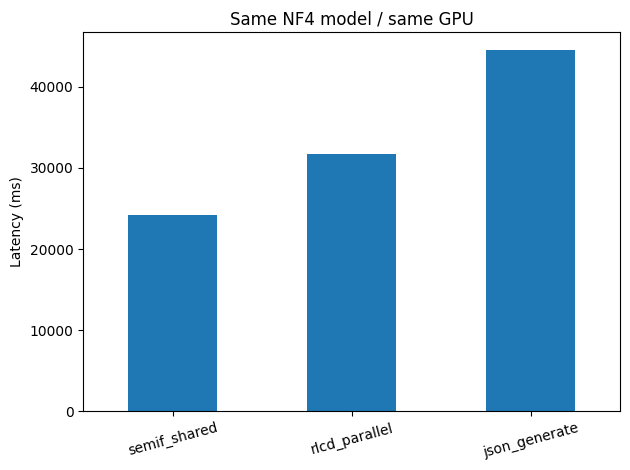

In [ ]:
import csv
from IPython.display import display
import pandas as pd
result = json.loads((OUT/'results.json').read_text())
assert result['status'] == 'SUCCESS', result.get('error')
table = pd.DataFrame(result['summary'])
table.to_csv(OUT/'comparison.csv',index=False)
display(table[['method','median_ms','correct_cases','total_cases','correct_fields','total_fields','valid_speed_runs','max_allocated_mib']])
print('캐시 검증:', result['semif_cache_check'])
print('RLCD 첫 토큰 충돌:', result['rlcd_collision_fields'])
print('JSON baseline은 프롬프트로만 JSON을 요청하며 grammar 강제 방식이 아닙니다.')
import matplotlib.pyplot as plt
ax = table.plot.bar(x='method',y='median_ms',legend=False,title='Same NF4 model / same GPU')
ax.set_ylabel('Latency (ms)'); ax.set_xlabel(''); plt.xticks(rotation=15)
plt.tight_layout(); plt.savefig(OUT/'latency.png',dpi=160); plt.show()


## 7. 선택: llama.cpp CUDA / Q4_K_M

RUN_LLAMA_CPP=True일 때만 실행합니다. 기본 비교가 끝난 후 모델을 따로 로딩합니다.
이 경로는 같은 계열의 **다른 양자화 가중치와 엔진**이며, 위 표와 순수 알고리즘 배속으로 비교하지 마세요.
GPU compute capability를 감지해 빌드하므로 A4000 바이너리를 T4에 복사하지 않습니다.


In [ ]:
if RUN_LLAMA_CPP:
    run([sys.executable,'-m','pip','install','-q','cmake','ninja'])
    checkout('https://github.com/thecodacus/llama.cpp.git','14d04e755fa28653e87b9a07072892265bdc0fad',ROOT/'llama.cpp')
    cap = ''.join(map(str,torch.cuda.get_device_capability()))
    run(['cmake','-S',ROOT/'llama.cpp','-B',ROOT/'build','-G','Ninja','-DCMAKE_BUILD_TYPE=Release',
         '-DGGML_CUDA=ON',f'-DCMAKE_CUDA_ARCHITECTURES={cap}','-DLLAMA_CURL=OFF','-DLLAMA_BUILD_TESTS=OFF','-DLLAMA_BUILD_EXAMPLES=OFF'])
    run(['cmake','--build',ROOT/'build','--target','llama-server','-j','2'])
    from huggingface_hub import hf_hub_download
    assert shutil.disk_usage(ROOT).free > sum(x['size'] for x in MODEL['gguf_files'])+2*2**30, 'GGUF 추가 저장 공간 필요'
    model_paths=[]
    for spec in MODEL['gguf_files']:
        path=hf_hub_download(MODEL['gguf_repo'],spec['filename'],revision=MODEL['gguf_revision'],local_dir=ROOT/'gguf')
        with open(path,'rb') as f: actual=hashlib.file_digest(f,'sha256').hexdigest()
        assert actual==spec['sha256'], spec['filename']
        model_paths.append(path)
    for label,script in [('llama14b','benchmark_llama.py'),('llama14b-structured','benchmark_structured.py')]:
        run([sys.executable,ROOT/'manage_llama.py','--exe',ROOT/'build/bin/llama-server','--model',model_paths[0],
             '--source',ROOT/'rlcd','--output-dir',OUT,'--label',label,'--seqs','8','--benchmark',script])
    print('llama.cpp 원본 결과/로그 저장 완료:',OUT)


qwen2.5-14b-instruct-q4_k_m-00001-of-000(…): reconstructing file:   0%|          |  0.00B / 3.99GB            

qwen2.5-14b-instruct-q4_k_m-00001-of-000(…): downloading bytes:           |  0.00B            

qwen2.5-14b-instruct-q4_k_m-00002-of-000(…): reconstructing file:   0%|          |  0.00B / 3.99GB            

qwen2.5-14b-instruct-q4_k_m-00002-of-000(…): downloading bytes:           |  0.00B            

qwen2.5-14b-instruct-q4_k_m-00003-of-000(…): reconstructing file:   0%|          |  0.00B / 1.01GB            

qwen2.5-14b-instruct-q4_k_m-00003-of-000(…): downloading bytes:           |  0.00B            

llama.cpp 원본 결과/로그 저장 완료: /content/decision-16gb/runs/20260922-043237-7fa17c


## 8. 결과 다운로드 — 실패 시에도 로그를 받을 수 있습니다

In [ ]:
(OUT/'reproduce-config.json').write_text(json.dumps(dict(model=MODEL,chunk_size=CHUNK_SIZE,repeats=REPEATS,
    run_json=RUN_JSON,smoke=SMOKE_ONLY),indent=2))
for name in ['compare.py','fixtures.json','models.json']:
    shutil.copy2(ROOT/name,OUT/name)
archive=shutil.make_archive(str(OUT),'zip',OUT)
from google.colab import files
files.download(archive)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 해석과 한계
- 속도는 28개 항목 완료 시간입니다. 정확도는 별도의 작은 문의 8개이며 서로 다른 데이터입니다.
- 같은 NF4 모델 객체를 공유하지만 원본 프롬프트·토큰 읽기 방식은 다릅니다.
- 2개씩 처리하므로 한 번의 모델 forward로 28개를 끝낸 결과가 아닙니다. 묶음 크기는 결과에 저장됩니다.
- SemIf 캐시 병렬화는 작은 수치 차이를 만들 수 있습니다. 선택이 달라져도 숨기지 않고 기록합니다.
- RLCD 첫 토큰 충돌과 JSON 형식 실패를 그대로 기록합니다. 실패한 출력을 정확도 분모에서 빼지 않습니다.
- 메모리 부족/지원하지 않는 CUDA 환경에서 성공을 보장하지 않습니다. 기존 작업을 임의 종료하지 않습니다.

출처: [SemIf](https://github.com/TheoLeeCJ/SemIf), [RLCD](https://huggingface.co/harshatheg/Qwen-2.5-1B-RLCD),
[Qwen2.5 14B](https://huggingface.co/Qwen/Qwen2.5-14B-Instruct), [Colab FAQ](https://research.google.com/colaboratory/faq.html).
